Question 2 Transaction Data
This notebook answers all five questions 


,Counterparty,Notional Amount
4,BRK 5,57081
3,BRK 4,56077
1,BRK 2,41175


,Execution Venue,Avg Tx Cost (% of price)
0,Venue 1,0.368104
1,Venue 2,0.373465
2,Venue 3,0.388888


,Counterparty,Avg Tx Cost (% of price)
3,BRK 4,0.359458
1,BRK 2,0.369356
2,BRK 3,0.385203
0,BRK 1,0.386259
4,BRK 5,0.391605


,Month,Execution Venue,Avg Tx Cost (% of price)
0,2025-01-01,Venue 1,0.401112
1,2025-01-01,Venue 2,0.415122
2,2025-01-01,Venue 3,0.404296
3,2025-02-01,Venue 1,0.348955
4,2025-02-01,Venue 2,0.466305


,Month,Counterparty,Avg Tx Cost (% of price)
0,2025-01-01,BRK 1,0.441904
1,2025-01-01,BRK 2,0.414806
2,2025-01-01,BRK 3,0.414804
3,2025-01-01,BRK 5,0.349165
4,2025-02-01,BRK 1,0.364095


,Settlement Bucket,Avg Tx Cost (% of price)
1,100k-1m,0.373720
0,0-100k,0.383001


,Instrument,Trade Count
2,Microsoft,46
4,Tesla,45
1,Google,42
0,Apple,40
3,Nvidia,29


,Trade Date,Abs Notional,Cumulative Turnover
0,2025-01-01,730,730
1,2025-01-03,578,1308
2,2025-01-05,1125,2433
3,2025-01-09,313,2746
4,2025-01-12,1206,3952


Annualized Turnover (Abs Notional): 301160.0


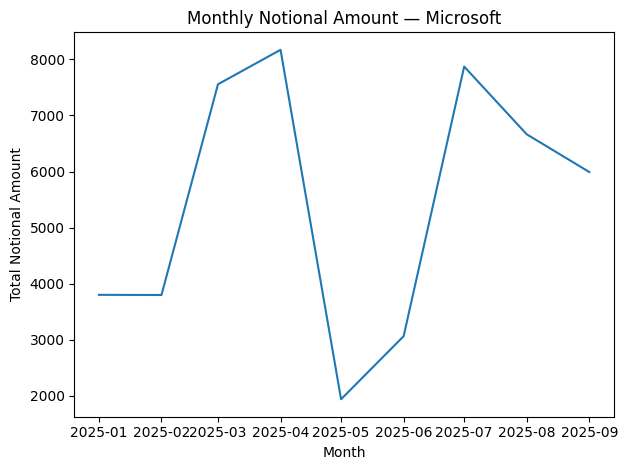

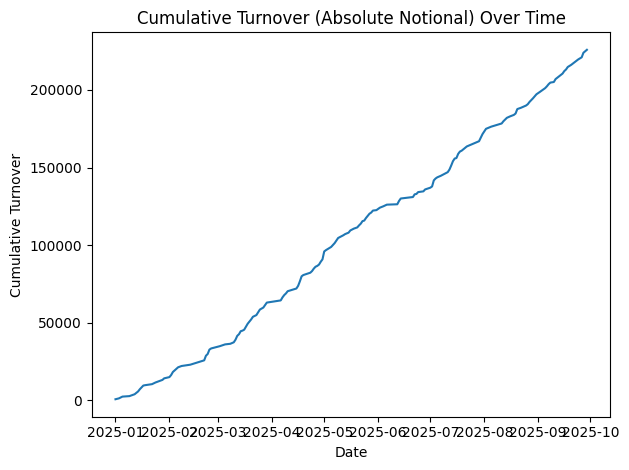

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "Question 2.xlsx"

# Detect header row
raw = pd.read_excel(FILE_PATH, sheet_name="Sheet1", header=None)
header_row_idx = None
for i in range(min(50, len(raw))):
    row_vals = raw.iloc[i].astype(str).str.strip().str.lower().tolist()
    if "trade id" in row_vals and "trade date" in row_vals:
        header_row_idx = i
        break
if header_row_idx is None:
    raise RuntimeError("Could not auto-detect header row.")

df = pd.read_excel(FILE_PATH, sheet_name="Sheet1", header=header_row_idx)

def normalize(col):
    c = str(col).strip()
    c = " ".join(c.split())
    c = c.replace("Notinal", "Notional")
    return c
df.columns = [normalize(c) for c in df.columns]

# Standard names
rename_map = {}
for c in df.columns:
    lc = c.lower()
    if lc.startswith("trade id"): rename_map[c] = "Trade ID"
    elif lc.startswith("trade date"): rename_map[c] = "Trade Date"
    elif lc.startswith("counterparty"): rename_map[c] = "Counterparty"
    elif lc.startswith("instrument"): rename_map[c] = "Instrument"
    elif "notional" in lc: rename_map[c] = "Notional Amount"
    elif lc == "price": rename_map[c] = "Price"
    elif lc.startswith("settlement"): rename_map[c] = "Settlement Amount"
    elif lc.startswith("trade direction"): rename_map[c] = "Trade Direction"
    elif lc.startswith("execution venue"): rename_map[c] = "Execution Venue"
    elif lc.startswith("transaction cost"): rename_map[c] = "Transaction Cost (% of price)"
df = df.rename(columns=rename_map)

# Types & cleaning
df["Trade Date"] = pd.to_datetime(df["Trade Date"], errors="coerce")
for col in ["Notional Amount","Price","Transaction Cost (% of price)","Settlement Amount"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Counterparty","Notional Amount"], how="any")
df["Month"] = df["Trade Date"].dt.to_period("M").dt.to_timestamp()

# Q1: Top 3 counterparties by notional
q1 = (df.groupby("Counterparty",as_index=False)["Notional Amount"].sum()
        .sort_values("Notional Amount", ascending=False).head(3))
display(q1)

# Q2/Q3: Best venue/counterparty by average tx cost
venue_cost = (df.dropna(subset=["Execution Venue","Transaction Cost (% of price)"])
                .groupby("Execution Venue",as_index=False)["Transaction Cost (% of price)"]
                .mean().rename(columns={"Transaction Cost (% of price)":"Avg Tx Cost (% of price)"})
                .sort_values("Avg Tx Cost (% of price)"))
display(venue_cost.head(10))

cp_cost = (df.dropna(subset=["Counterparty","Transaction Cost (% of price)"])
             .groupby("Counterparty",as_index=False)["Transaction Cost (% of price)"]
             .mean().rename(columns={"Transaction Cost (% of price)":"Avg Tx Cost (% of price)"})
             .sort_values("Avg Tx Cost (% of price)"))
display(cp_cost.head(10))

# Seasonality views
monthly_venue = (df.dropna(subset=["Month","Execution Venue","Transaction Cost (% of price)"])
                   .groupby(["Month","Execution Venue"],as_index=False)["Transaction Cost (% of price)"]
                   .mean().rename(columns={"Transaction Cost (% of price)":"Avg Tx Cost (% of price)"}))
display(monthly_venue.head())

monthly_cp = (df.dropna(subset=["Month","Counterparty","Transaction Cost (% of price)"])
                .groupby(["Month","Counterparty"],as_index=False)["Transaction Cost (% of price)"]
                .mean().rename(columns={"Transaction Cost (% of price)":"Avg Tx Cost (% of price)"}))
display(monthly_cp.head())

# Settlement bucket function
def settlement_bucket(val):
    if pd.isna(val): return "Unknown"
    v = float(val)
    if v < 0: return "Negative"
    if v == 0: return "Zero"
    if 0 < v <= 100_000: return "0-100k"
    if 100_000 < v <= 1_000_000: return "100k-1m"
    return ">1m"

df["Settlement Bucket"] = df["Settlement Amount"].apply(settlement_bucket) if "Settlement Amount" in df.columns else "Unknown"

bucket_cost = (df.dropna(subset=["Transaction Cost (% of price)"])
                 .groupby("Settlement Bucket",as_index=False)["Transaction Cost (% of price)"]
                 .mean().rename(columns={"Transaction Cost (% of price)":"Avg Tx Cost (% of price)"})
                 .sort_values("Avg Tx Cost (% of price)"))
display(bucket_cost)

# Q4: Most frequently traded instrument & monthly notional chart
instr_freq = (df.groupby("Instrument",as_index=False)["Trade ID"].count()
                .rename(columns={"Trade ID":"Trade Count"})
                .sort_values("Trade Count", ascending=False))
display(instr_freq.head(20))

if len(instr_freq):
    top_instr = instr_freq.iloc[0]["Instrument"]
    top_instr_ts = (df[df["Instrument"]==top_instr]
                      .dropna(subset=["Month","Notional Amount"])
                      .groupby("Month",as_index=False)["Notional Amount"].sum()
                      .sort_values("Month"))
    plt.figure()
    plt.plot(top_instr_ts["Month"], top_instr_ts["Notional Amount"])
    plt.title(f"Monthly Notional Amount — {top_instr}")
    plt.xlabel("Month"); plt.ylabel("Total Notional Amount"); plt.tight_layout()

# Q5: Cumulative & annualized turnover
turn_df = df.dropna(subset=["Trade Date","Notional Amount"]).copy().sort_values("Trade Date")
turn_df["Abs Notional"] = turn_df["Notional Amount"].abs()

daily_turn = (turn_df.groupby("Trade Date",as_index=False)["Abs Notional"].sum()
                        .sort_values("Trade Date"))
daily_turn["Cumulative Turnover"] = daily_turn["Abs Notional"].cumsum()
display(daily_turn.head())

plt.figure()
plt.plot(daily_turn["Trade Date"], daily_turn["Cumulative Turnover"])
plt.title("Cumulative Turnover (Absolute Notional) Over Time")
plt.xlabel("Date"); plt.ylabel("Cumulative Turnover"); plt.tight_layout()

monthly_turn = (turn_df.groupby(turn_df["Trade Date"].dt.to_period("M"))["Abs Notional"]
                          .sum().reset_index())
monthly_turn["Trade Date"] = monthly_turn["Trade Date"].dt.to_timestamp()
avg_monthly_turnover = monthly_turn["Abs Notional"].mean() if len(monthly_turn) else np.nan
annualized_turnover = 12 * avg_monthly_turnover if pd.notnull(avg_monthly_turnover) else np.nan
print("Annualized Turnover (Abs Notional):", annualized_turnover)


Answers

### Q1 – Insight
Top 3 counterparties by total notional are **BRK 5**, **BRK 4**, **BRK 2**.
Together, they represent **68.33%** of overall portfolio notional.


### Q2/Q3 – Insight
- **Best Execution Venue:** **Venue 1** with lowest average transaction cost **0.3681%** of price.
- **Best Counterparty:** **BRK 4** with lowest average transaction cost **0.3595%** of price.

Seasonality plots in the notebook show monthly variation in average transaction cost for each venue/counterparty.


### Q3 – Settlement Bucket Insight
Lowest average transaction cost occurs in **100k-1m** bucket (**0.3737%**).  
This indicates execution cost is influenced by settlement size/type; compare bucket table for gradients across size bands.


### Q4 – Insight
Most frequently traded instrument: **Microsoft**.  
See the monthly notional line chart for seasonality in traded volume.


### Q5 – Insight
Annualized turnover (absolute notional basis): **301,160**.  
The cumulative turnover curve highlights periods of heightened trading activity.
